# Feature Extraction

## Goal

Transform preprocessed EEG signals into numerical features suitable for machine learning classification.

## Background

Machine learning models can't directly interpret raw EEG waveforms, so we extract informative features that summarize neural activity. In this notebook, I will begin by exploring the structure of the epochs before computing features for classification.

In [1]:
import mne

epochs = mne.read_epochs(
    "../data/subject1_motor_imagery-epo.fif",
    preload=True
)

print(epochs)

Reading /Users/ceciliajia/Desktop/eeg-motor-imagery-classification/notebooks/../data/subject1_motor_imagery-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 45 events (all good), 0 – 4 s (baseline off), ~14.1 MiB, data loaded,
 'class_1': 21
 'class_2': 24>


In [2]:
X = epochs.get_data()
y = epochs.events[:, 2]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45, 64, 641)
y shape: (45,)


In [3]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} trials")

Class 2: 21 trials
Class 3: 24 trials


In [4]:
trial = X[0]

print(trial.shape)

(64, 641)


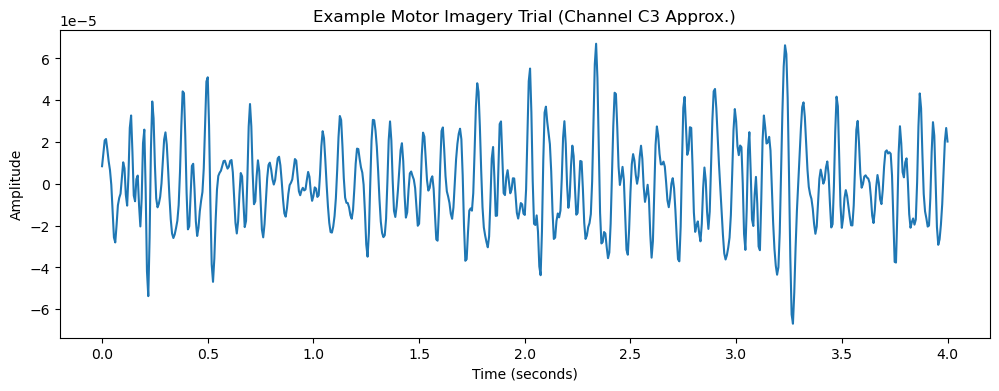

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(epochs.times, X[0, 8])
plt.title("Example Motor Imagery Trial (Channel C3 Approx.)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()